引入套件

In [1]:
import streamlit as st
import pandas as pd
import os
import zipfile
import io
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
sns.set_theme(style="whitegrid")
%matplotlib inline
results_data = []



In [2]:
import pandas as pd
import os

# 1. 定義你的 Mac 桌面路徑
# 建議使用原始字串 r'' 避免路徑符號出問題
data_path = "/Users/naomi/Desktop/projet（1）/data/storke.csv"

# 2. 檢查檔案是否存在並讀取
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    
    # --- 【自動標記核心】 ---
    # 取得最後一欄的名稱 (不論它叫 stroke 還是其他名字)
    target_col = df.columns[-1] 
    
    # 3. 數據預覽與診斷
    print(f"✅ 成功載入檔案：{os.path.basename(data_path)}")
    print(f"🎯 自動識別 Target 欄位: {target_col}")
    
    # 4. 檢查中風 (1) 與健康 (0) 的數量
    # 就算前幾列都是 0，這行會告訴你整份資料有多少個 1
    counts = df[target_col].value_counts()
    print(f"📊 類別分佈:\n{counts}")

    # 5. 清理：移除 id 欄位 (它對預測沒幫助)
    if 'id' in df.columns:
        df = df.drop(columns=['id'])
        print("🗑️ 已移除 id 欄位")
else:
    print("❌ 找不到檔案，請檢查資料夾名稱是否包含全形括號 (1)")


✅ 成功載入檔案：storke.csv
🎯 自動識別 Target 欄位: stroke
📊 類別分佈:
stroke
0    4861
1     249
Name: count, dtype: int64
🗑️ 已移除 id 欄位


In [3]:
import os
import pandas as pd

# 1. 設定基礎路徑 (確保與你的資料夾層級一致)
data_dir = "../data" 
files = ["diabetes.csv", "heart_disease.csv", "storke.csv"] # 或是 "storke.csv"

# 2. 用來存放結果的字典
all_datasets = {}

# 3. 執行迴圈：讀取、自動抓取最後一欄作為 Target
for filename in files:
    full_path = os.path.join(data_dir, filename)
    
    if os.path.exists(full_path):
        # 讀取 CSV
        df = pd.read_csv(full_path)
        
        # --- 【核心邏輯】取得最後一欄並標記成 target ---
        target_name = df.columns[-1] 
        
        # 進行簡單的清理 (例如移除 ID，不分大小寫)
        id_cols = [c for c in df.columns if c.lower() == 'id']
        if id_cols:
            df = df.drop(columns=id_cols)
            # 重新取得最後一欄名稱，確保 target 還是最後一個
            target_name = df.columns[-1] 
            
        # --- 【診斷區】檢查標籤分佈 (回答你全 0 的疑惑) ---
        counts = df[target_name].value_counts()
        pos_cases = counts.get(1, 0) # 取得 1 (有病) 的數量，沒有則為 0
        
        # 存入字典
        dataset_key = filename.split('.')[0].capitalize()
        all_datasets[dataset_key] = (df, target_name)
        
        print(f"✅ {dataset_key:12} | Target: {target_name:15} | 案例數: {pos_cases}")
    else:
        print(f"❌ 找不到檔案: {filename}，請檢查路徑或拼字！")



✅ Diabetes     | Target: Outcome         | 案例數: 268
✅ Heart_disease | Target: target          | 案例數: 265
✅ Storke       | Target: stroke          | 案例數: 249


In [4]:

for filename in files:
     if os.path.exists(full_path):
        # 讀取 CSV
        df = pd.read_csv(full_path)

        print(f"📊 Dataset Shape: {df.shape}")
        print(f"dataset Name:{filename}")
        display(df.head())


📊 Dataset Shape: (5110, 12)
dataset Name:diabetes.csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


📊 Dataset Shape: (5110, 12)
dataset Name:heart_disease.csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


📊 Dataset Shape: (5110, 12)
dataset Name:storke.csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


🔍 開始執行全資料集維度與品質分析...

📂 資料集: Diabetes
   - 維度 (Shape): 768 筆樣本 x 9 個欄位
   - 目標欄位 (Target): Outcome


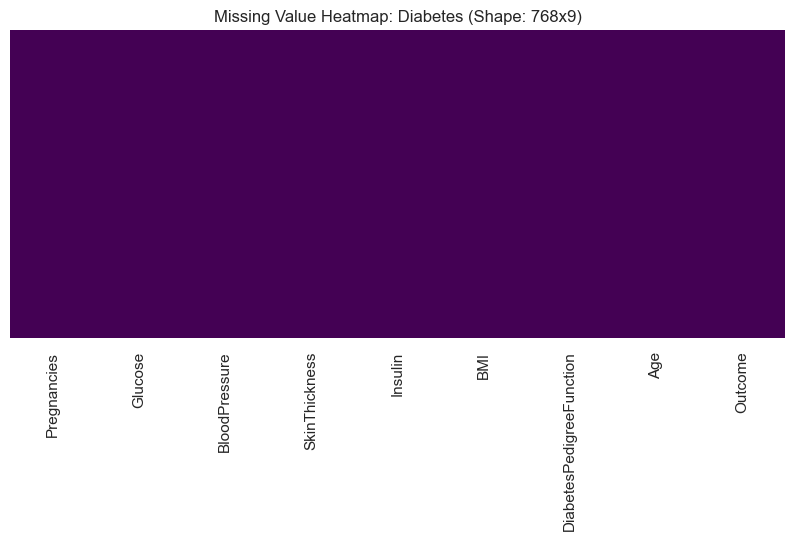


📂 資料集: Heart_disease
   - 維度 (Shape): 920 筆樣本 x 14 個欄位
   - 目標欄位 (Target): target


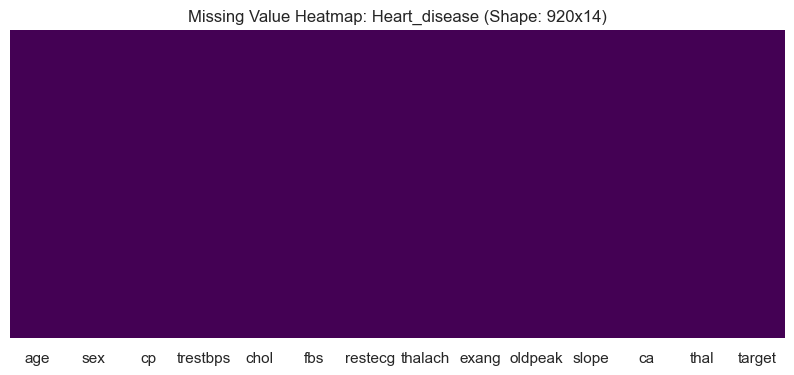


📂 資料集: Storke
   - 維度 (Shape): 5110 筆樣本 x 11 個欄位
   - 目標欄位 (Target): stroke


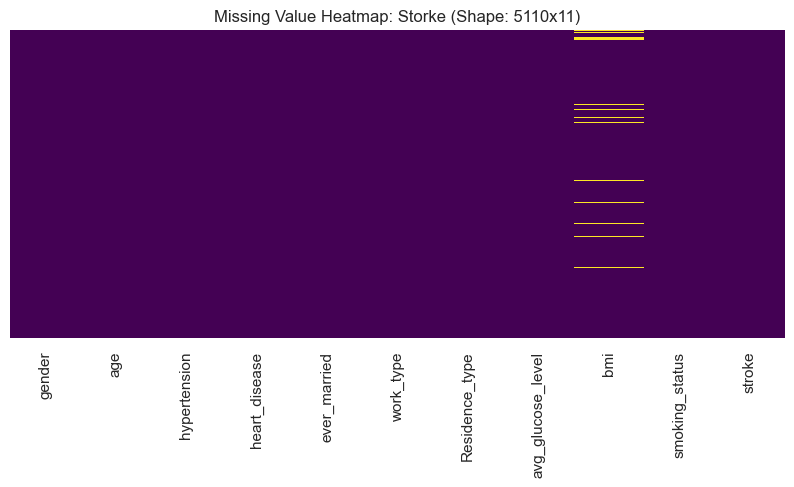

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 📊 批次數據分析：Shape 與 缺失值熱圖 ---
print("🔍 開始執行全資料集維度與品質分析...")

for name, (df_item, target) in all_datasets.items():
    # 1. 印出基本維度 (Shape)
    rows, cols = df_item.shape
    print(f"\n📂 資料集: {name}")
    print(f"   - 維度 (Shape): {rows} 筆樣本 x {cols} 個欄位")
    print(f"   - 目標欄位 (Target): {target}")
    
    # 2. 繪製缺失值熱圖 (Missing Value Heatmap)
    # 這是為了檢查清理後是否還有遺漏值
    plt.figure(figsize=(10, 4))
    sns.heatmap(df_item.isnull(), yticklabels=False, cbar=False, cmap='viridis')
    plt.title(f"Missing Value Heatmap: {name} (Shape: {rows}x{cols})")
    
    # 重要：在迴圈中使用 plt.show() 確保每張圖都會獨立跳出來
    plt.show() 
    
   

In [6]:
from sklearn.model_selection import train_test_split

# 1. 用來存放切割後結果的字典
split_data = {}

print("✂️ 開始批次資料切割 (Training/Test Split)...")
print("-" * 50)

for name, (df_item, target) in all_datasets.items():
    # 準備特徵 X 與標籤 y
    X = df_item.drop(columns=[target])
    y = df_item[target]
    
    # --- 【關鍵】執行切割 ---
    # test_size=0.2 代表 20% 測試集
    # stratify=y 確保兩邊的生病比例一致 (非常重要！)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 2. 將四個變數存入字典
    split_data[name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'target': target
    }
    
    print(f"✅ {name:12} | 訓練集: {X_train.shape[0]} 筆 | 測試集: {X_test.shape[0]} 筆")

print("-" * 50)
print("📦 所有資料集切割完成，準備進入 EBM 模型訓練！")

✂️ 開始批次資料切割 (Training/Test Split)...
--------------------------------------------------
✅ Diabetes     | 訓練集: 614 筆 | 測試集: 154 筆
✅ Heart_disease | 訓練集: 736 筆 | 測試集: 184 筆
✅ Storke       | 訓練集: 4088 筆 | 測試集: 1022 筆
--------------------------------------------------
📦 所有資料集切割完成，準備進入 EBM 模型訓練！


In [7]:
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

# 1. 用來存放訓練好的模型物件，方便之後做 Local 局部解釋
trained_models = {}

print("🤖 開始批次訓練 EBM 模型 (Explainable Boosting Machine)...")
print("-" * 60)

for name, data in split_data.items():
    print(f"⏳ 正在訓練資料集: {name}...")
    
    # A. 初始化模型

# 根據論文建議的參數進行設定 
   # A. 初始化模型
# 根據論文建議的參數進行設定 (Reference Parameters)
    ebm = ExplainableBoostingClassifier(
        inner_bags=100,      # 論文建議：100
        outer_bags=100,      # 論文建議：100
        learning_rate=0.01,  # 論文建議：0.01
        max_rounds=5000      # 論文建議：5000 epochs
    )

    # 執行訓練 (這一步會花比較多時間，因為參數調高了)
    ebm.fit(X_train, y_train)

    # 2. Generate Explanations
    ebm_global = ebm.explain_global()

# 3. Visualize
    # C. 存入字典備用
    trained_models[name] = ebm
    
    # D. 即時產生全域解釋 (Global Explanation)
    # 這會在 Notebook 裡彈出一個互動式儀表板
    ebm_global = ebm.explain_global(name=f"{name} - Global Explanation")
    
    print(f"✅ {name} 訓練完成！正在顯示全域解釋圖表...")
    show([ebm_global, ebm_local]) [cite: 99]
    print("-" * 60)

    print("🚀 所有 EBM 模型訓練與全域分析已完成！")


🤖 開始批次訓練 EBM 模型 (Explainable Boosting Machine)...
------------------------------------------------------------
⏳ 正在訓練資料集: Diabetes...


/opt/anaconda3/envs/med_ai/lib/python3.9/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


KeyboardInterrupt: 

📈 開始評估 EBM 模型性能 (支援多類別與二元 ROC)...
------------------------------------------------------------


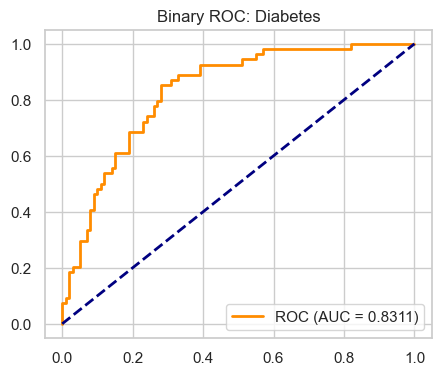

✅ Diabetes     評估完成。


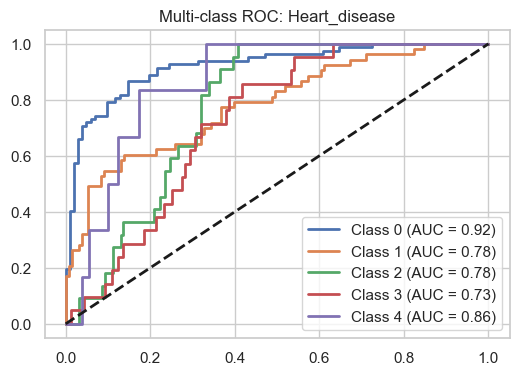

✅ Heart_disease 評估完成。


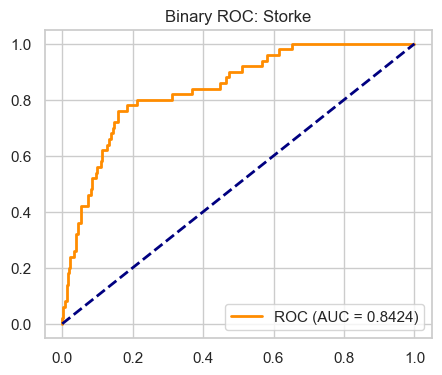

✅ Storke       評估完成。

📊 最終模型表現對照表 (Summary Table):


,Dataset,Classes,Test AUC
0,Diabetes,2,0.8311
1,Heart_disease,5,0.8137
2,Storke,2,0.8424


In [117]:
from sklearn.preprocessing import label_binarize
performance_results = []

print("📈 開始評估 EBM 模型性能 (支援多類別與二元 ROC)...")
print("-" * 60)

for name, model in trained_models.items():
    # 取得測試資料
    X_test = split_data[name]['X_test']
    y_test = split_data[name]['y_test']
    
    # 取得預測機率
    y_probs = model.predict_proba(X_test)
    unique_classes = len(np.unique(y_test))
    
    # --- A. 計算 AUC ---
    if unique_classes > 2:
        auc_score = roc_auc_score(y_test, y_probs, multi_class='ovr', average='macro')
    else:
        auc_score = roc_auc_score(y_test, y_probs[:, 1])

    # 存入結果清單
    performance_results.append({
        "Dataset": name,
        "Classes": unique_classes,
        "Test AUC": f"{auc_score:.4f}"
    })
    
    # --- B. 繪圖邏輯 (必須在 for 迴圈內) ---
    if unique_classes > 2:
        # 多類別 OVR 繪圖
        classes_OVR = np.unique(y_test)
        y_test_binarized = label_binarize(y_test, classes=classes_OVR)
        
        plt.figure(figsize=(6, 4))
        for i in range(unique_classes):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_probs[:, i])
            current_auc = roc_auc_score(y_test_binarized[:, i], y_probs[:, i])
            plt.plot(fpr, tpr, lw=2, label=f'Class {classes_OVR[i]} (AUC = {current_auc:.2f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.title(f'Multi-class ROC: {name}')
        plt.legend(loc="lower right")
        plt.show()  # 💡 確保圖表彈出
    else:
        # 二元分類繪圖
        fpr, tpr, _ = roc_curve(y_test, y_probs[:, 1])
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_score:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.title(f'Binary ROC: {name}')
        plt.legend(loc="lower right")
        plt.show()  # 💡 確保圖表彈出

    print(f"✅ {name:12} 評估完成。")

# --- C. 顯示總表 (在迴圈外面) ---
results_df = pd.DataFrame(performance_results)
print("\n📊 最終模型表現對照表 (Summary Table):")
display(results_df)

In [118]:
from interpret import show

print("🎯 Generating Local Explanation plots (Individual Diagnostic Reason)...")
print("-" * 60)

for name, model in trained_models.items():
    # 1. Prepare the data for a single patient (First row of test set)
    X_test = split_data[name]['X_test']
    y_test = split_data[name]['y_test']
    
    # We take the first instance [0] as an example
    # You can change '0' to any index to see different patients
    sample_idx = 0
    X_instance = X_test.iloc[[sample_idx]]
    y_instance = y_test.iloc[[sample_idx]]
    
    # 2. Generate the Local Explanation object
    ebm_local = model.explain_local(X_instance, y_instance, name=f"{name} Case Analysis")
    
    # 3. DIRECT VISUALIZATION (This creates the chart in your image)
    # visualize(0) means show the plot for the first (and only) person in this subset
    print(f"🏥 Dataset: {name} | Analyzing Patient #{sample_idx}")
    
    # This line renders the bar chart directly in your Jupyter cell
    ebm_local.visualize(0).show()
    
    print("-" * 60)

print("✅ All local case diagnostic charts have been generated.")

🎯 Generating Local Explanation plots (Individual Diagnostic Reason)...
------------------------------------------------------------
🏥 Dataset: Diabetes | Analyzing Patient #0


------------------------------------------------------------
🏥 Dataset: Heart_disease | Analyzing Patient #0


------------------------------------------------------------
🏥 Dataset: Storke | Analyzing Patient #0


------------------------------------------------------------
✅ All local case diagnostic charts have been generated.


In [119]:
print("🌍 Generating Global Explanation plots (Population-Level Insights)...")
print("-" * 60)

for name, model in trained_models.items():
    # 1. 產生全域解釋物件
    ebm_global = model.explain_global(name=f"{name} Global Analysis")
    
    # 2. 直接呼叫視覺化並顯示 (靜態條形圖)
    print(f"📊 Dataset: {name} | Overall Feature Importance")
    
    # visualize() 會渲染出該資料集的特徵權重排名
    ebm_global.visualize().show()
    
    print("-" * 60)

print("✅ All global feature importance charts have been generated.")

🌍 Generating Global Explanation plots (Population-Level Insights)...
------------------------------------------------------------
📊 Dataset: Diabetes | Overall Feature Importance


------------------------------------------------------------
📊 Dataset: Heart_disease | Overall Feature Importance


/opt/anaconda3/envs/med_ai/lib/python3.9/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term age & cp from explanation since we can't graph multinomial interactions.
  warn(
/opt/anaconda3/envs/med_ai/lib/python3.9/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term age & chol from explanation since we can't graph multinomial interactions.
  warn(
/opt/anaconda3/envs/med_ai/lib/python3.9/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term age & fbs from explanation since we can't graph multinomial interactions.
  warn(
/opt/anaconda3/envs/med_ai/lib/python3.9/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term age & restecg from explanation since we can't graph multinomial interactions.
  warn(
/opt/anaconda3/envs/med_ai/lib/python3.9/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term age & thalach from explanation since we can't graph multinomial inte

------------------------------------------------------------
📊 Dataset: Storke | Overall Feature Importance


------------------------------------------------------------
✅ All global feature importance charts have been generated.


In [120]:
import pandas as pd
import numpy as np

# 1. 建立一個清單來存放摘要數據
summary_list = []

print("📊 Generating Clinical Model Benchmarking Summary...")
print("-" * 70)

for name, (df_item, target) in all_datasets.items():
    # A. 基本維度
    total_samples = len(df_item)
    feature_count = len(df_item.columns) - 1
    
    # B. 計算正例比例 (Positive Ratio)
    # 假設 1 代表有病。如果是多類別，我們會算非 0 的比例
    pos_count = (df_item[target] != 0).sum()
    pos_ratio = (pos_count / total_samples) * 100
    
    # C. 取得該資料集的 AUC (從之前的 performance_results 找)
    # 這裡假設你的 results_df 已經產生
    auc_val = results_df[results_df['Dataset'] == name]['Test AUC'].values[0]
    
    # 2. 存入字典
    summary_list.append({
        "Dataset (資料集)": name,
        "Samples (樣本數)": total_samples,
        "Features (特徵數)": feature_count,
        "Positive Ratio (正例比例)": f"{pos_ratio:.2f}%",
        "EBM Test AUC": auc_val
    })

# 3. 轉換為 DataFrame 並顯示
final_summary_df = pd.DataFrame(summary_list)

# 顯示表格
print("✨ Final Project Summary Table:")
display(final_summary_df)

📊 Generating Clinical Model Benchmarking Summary...
----------------------------------------------------------------------
✨ Final Project Summary Table:


,Dataset (資料集),Samples (樣本數),Features (特徵數),Positive Ratio (正例比例),EBM Test AUC
0,Diabetes,768,8,34.90%,0.8311
1,Heart_disease,920,13,55.33%,0.8137
2,Storke,5110,10,4.87%,0.8424
